In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.metrics import roc_curve
import xgboost as xgb
from sklearn.metrics import roc_curve, auc

In [2]:
df = pd.read_csv("./playground-series-s6e5/train.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 439140 entries, 0 to 439139
Data columns (total 16 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      439140 non-null  int64  
 1   Driver                  439140 non-null  str    
 2   Compound                439140 non-null  str    
 3   Race                    439140 non-null  str    
 4   Year                    439140 non-null  int64  
 5   PitStop                 439140 non-null  int64  
 6   LapNumber               439140 non-null  int64  
 7   Stint                   439140 non-null  int64  
 8   TyreLife                439140 non-null  float64
 9   Position                439140 non-null  int64  
 10  LapTime (s)             439140 non-null  float64
 11  LapTime_Delta           439140 non-null  float64
 12  Cumulative_Degradation  439140 non-null  float64
 13  RaceProgress            439140 non-null  float64
 14  Position_Change         439140 

In [3]:
categorical_columns = ["Compound", "Race"]

encoder = OneHotEncoder(sparse_output=False)

one_hot_encoded = encoder.fit_transform(df[categorical_columns])

one_hot_df = pd.DataFrame(one_hot_encoded, columns=encoder.get_feature_names_out(categorical_columns))

df_new = pd.concat([df.drop(categorical_columns, axis=1), one_hot_df], axis=1)

df_new.info()

<class 'pandas.DataFrame'>
RangeIndex: 439140 entries, 0 to 439139
Data columns (total 45 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id                              439140 non-null  int64  
 1   Driver                          439140 non-null  str    
 2   Year                            439140 non-null  int64  
 3   PitStop                         439140 non-null  int64  
 4   LapNumber                       439140 non-null  int64  
 5   Stint                           439140 non-null  int64  
 6   TyreLife                        439140 non-null  float64
 7   Position                        439140 non-null  int64  
 8   LapTime (s)                     439140 non-null  float64
 9   LapTime_Delta                   439140 non-null  float64
 10  Cumulative_Degradation          439140 non-null  float64
 11  RaceProgress                    439140 non-null  float64
 12  Position_Change            

In [4]:
var = [c for c in df_new.columns if c not in ["id", "PitNextLap", "Driver"]]
target_variable = "PitNextLap"


X = df_new[var]
y = df_new[target_variable]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

In [5]:
param_dist = {
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'n_estimators': [100, 500, 1000],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'device': ['cuda']
}


random_search = RandomizedSearchCV(
    estimator=xgb.XGBClassifier(objective='binary:logistic'),
    param_distributions=param_dist,
    n_iter=15,
    scoring='roc_auc',
    cv=3,
    verbose=1,
    random_state=1,
    n_jobs=1
)



random_search.fit(X_train, y_train)

best_xgb = random_search.best_estimator_
y_score = best_xgb.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)


print(f"Best parameters: {random_search.best_params_}")
print(f"Best AUC in CV: {random_search.best_score_:.4f}")

Fitting 3 folds for each of 15 candidates, totalling 45 fits


/home/elia/UNI/3r/2n semestre/venv/lib/python3.13/site-packages/xgboost/core.py:751: UserWarning: [11:28:33] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


Best parameters: {'subsample': 0.8, 'n_estimators': 1000, 'max_depth': 5, 'learning_rate': 0.1, 'device': 'cuda', 'colsample_bytree': 0.8}
Best AUC in CV: 0.9473


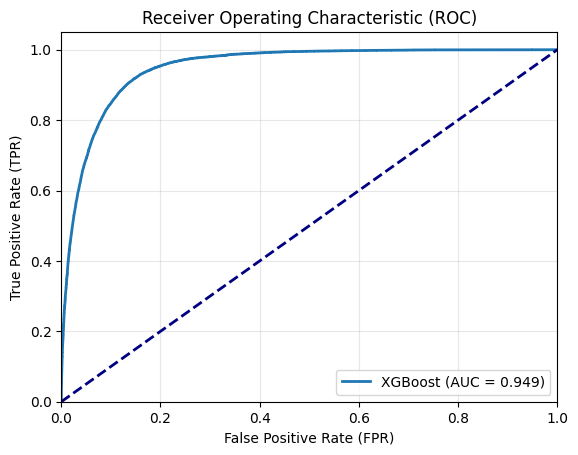

Final Model AUC: 0.9490


In [6]:
best_params = {**random_search.best_params_}

final_xgb = xgb.XGBClassifier(**best_params)

final_xgb.fit(X_train, y_train)

y_score = final_xgb.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, lw=2, label=f'XGBoost (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()


print(f"Final Model AUC: {roc_auc:.4f}")

In [7]:
df_test_final = pd.read_csv('./playground-series-s6e5/test.csv') 

categorical_columns = ["Compound", "Race"]

one_hot_encoded_test = encoder.transform(df_test_final[categorical_columns])
one_hot_df_test = pd.DataFrame(one_hot_encoded_test, columns=encoder.get_feature_names_out(categorical_columns))

df_test_processed = pd.concat([df_test_final.drop(categorical_columns, axis=1), one_hot_df_test], axis=1)

test_features = df_test_processed[var]

kaggle_probabilities = best_xgb.predict_proba(test_features)[:, 1]

submission = pd.DataFrame({
    'id': df_test_final['id'], 
    'target': kaggle_probabilities
})
submission.to_csv('submission.csv', index=False)
print("Submission file ready!")

Submission file ready!
